In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


# **Model: Decision Tree**

In [2]:
X_train = pd.read_csv("../data/X_train.csv", index_col=0)
X_test = pd.read_csv("../data/X_test.csv", index_col=0)
y_train = pd.read_csv("../data/y_train.csv", index_col=0).squeeze()
y_test = pd.read_csv("../data/y_test.csv", index_col=0).squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (78415, 10)
X_test shape: (19604, 10)


# **Baseline**

In [3]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.54


In [4]:
categorical_cols = X_train.select_dtypes("object").columns.tolist()
numeric_cols = X_train.select_dtypes("number").columns.tolist()
categorical_cols, numeric_cols

/tmp/ipykernel_519/1257538748.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes("object").columns.tolist()


(['land_surface_condition',
  'foundation_type',
  'roof_type',
  'ground_floor_type',
  'other_floor_type',
  'position',
  'plan_configuration'],
 ['age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq'])

# **Hyper parameter Tuning**

In [5]:
# ordinal encoding this time instead of one-hot -- trees split on thresholds,
# so they don't need dummy columns the way linear models do
preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_cols),
], remainder="passthrough")

depth_hyperparams = range(1, 21)
training_acc = []
validation_acc = []

for d in depth_hyperparams:
    m = Pipeline([
        ("preprocessor", preprocessor),
        ("decisiontreeclassifier", DecisionTreeClassifier(max_depth=d, random_state=42))
    ])
    m.fit(X_train, y_train)
    training_acc.append(m.score(X_train, y_train))
    validation_acc.append(m.score(X_test, y_test))

print("done")

done


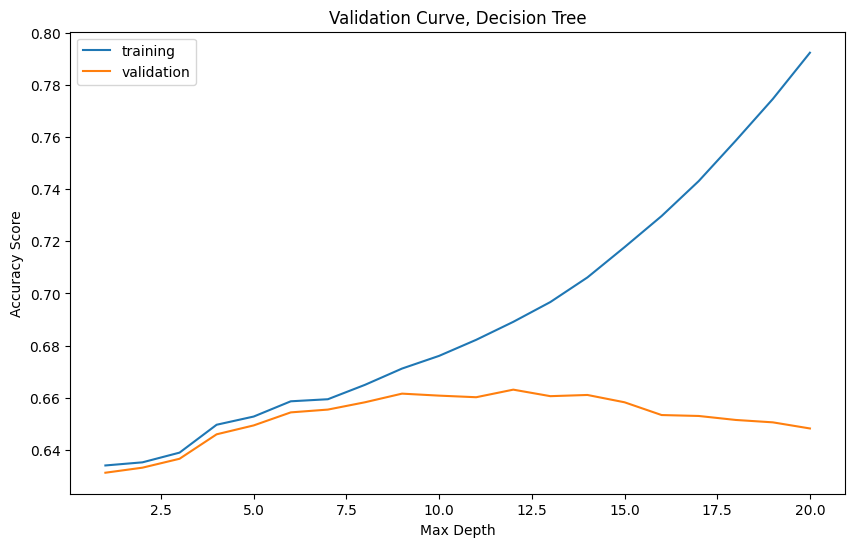

In [6]:
plt.figure(figsize=(10,6))
plt.plot(depth_hyperparams, training_acc, label="training")
plt.plot(depth_hyperparams, validation_acc, label="validation")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy Score")
plt.title("Validation Curve, Decision Tree")
plt.legend()
plt.savefig("../images/dtree_validation_curve.png", dpi=150)
plt.show()


In [7]:
best_depth = depth_hyperparams[int(np.argmax(validation_acc))]
print("Best max_depth:", best_depth)

Best max_depth: 12


# **Build Model**

In [8]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("decisiontreeclassifier", DecisionTreeClassifier(max_depth=best_depth, random_state=42))
])
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

# **Evaluate**

In [9]:
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = accuracy_score(y_test, model.predict(X_test))

print("Training Accuracy:", round(acc_train, 3))
print("Test Accuracy:", round(acc_test, 3))

Training Accuracy: 0.689
Test Accuracy: 0.663


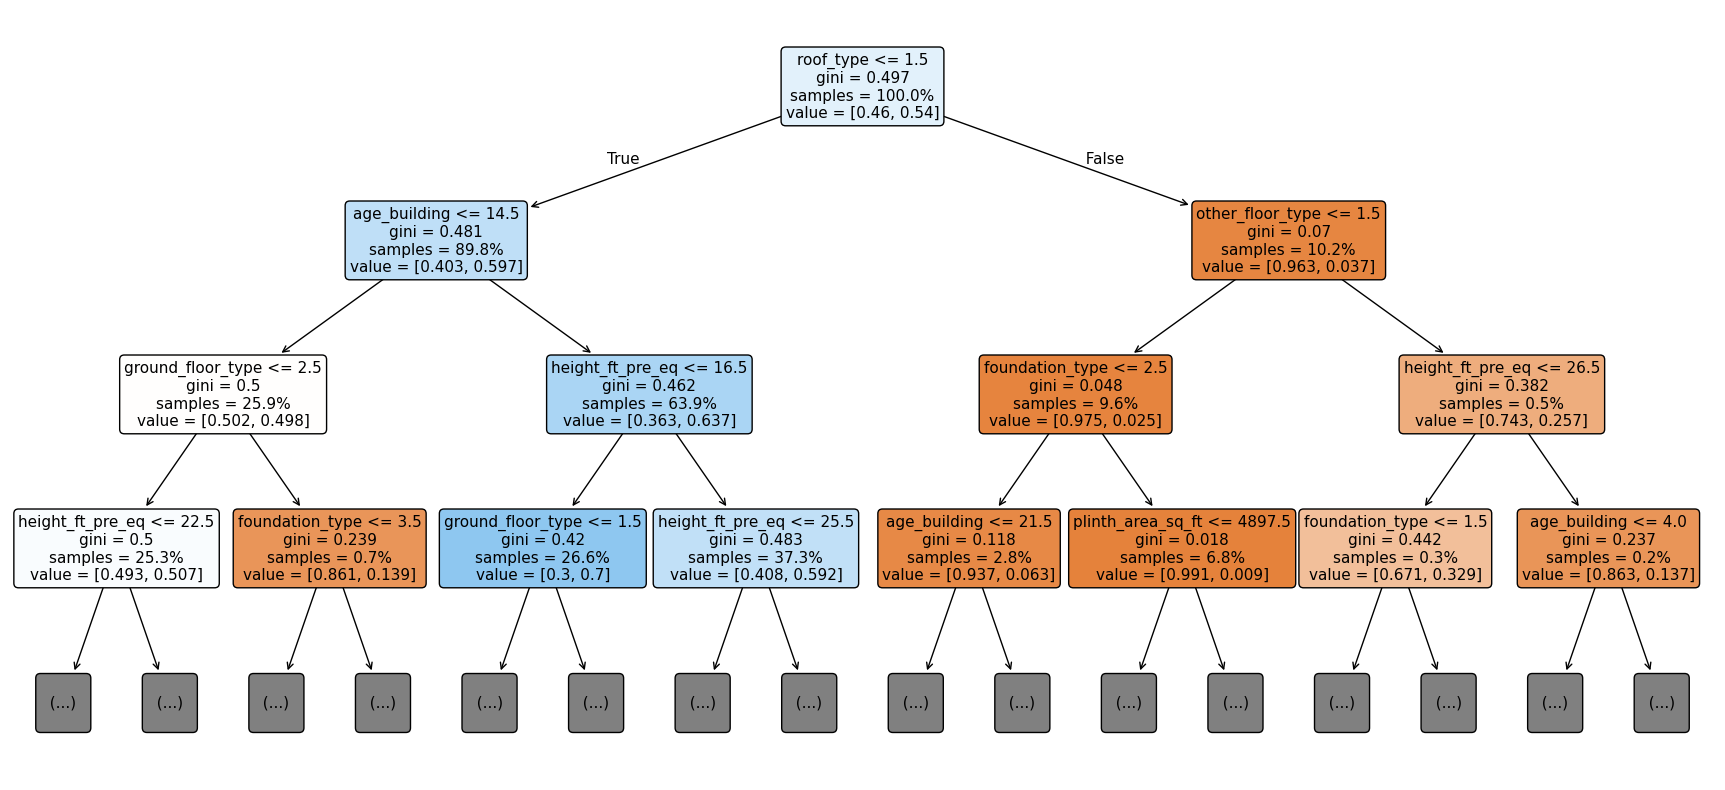

In [10]:
fig, ax = plt.subplots(figsize=(22,10))
plot_tree(
    model.named_steps["decisiontreeclassifier"],
    feature_names=categorical_cols + numeric_cols,
    filled=True, rounded=True, proportion=True, max_depth=3, fontsize=11, ax=ax
)
plt.savefig("../images/dtree_plot.png", dpi=150)
plt.show()


# **Communicate Results**

In [11]:
all_features = categorical_cols + numeric_cols
importances = model.named_steps["decisiontreeclassifier"].feature_importances_

feat_imp = pd.Series(importances, index=all_features).sort_values()
feat_imp

plan_configuration        0.006531
position                  0.013637
land_surface_condition    0.016955
foundation_type           0.017936
ground_floor_type         0.033363
other_floor_type          0.034687
plinth_area_sq_ft         0.103797
height_ft_pre_eq          0.109999
age_building              0.124119
roof_type                 0.538978
dtype: float64

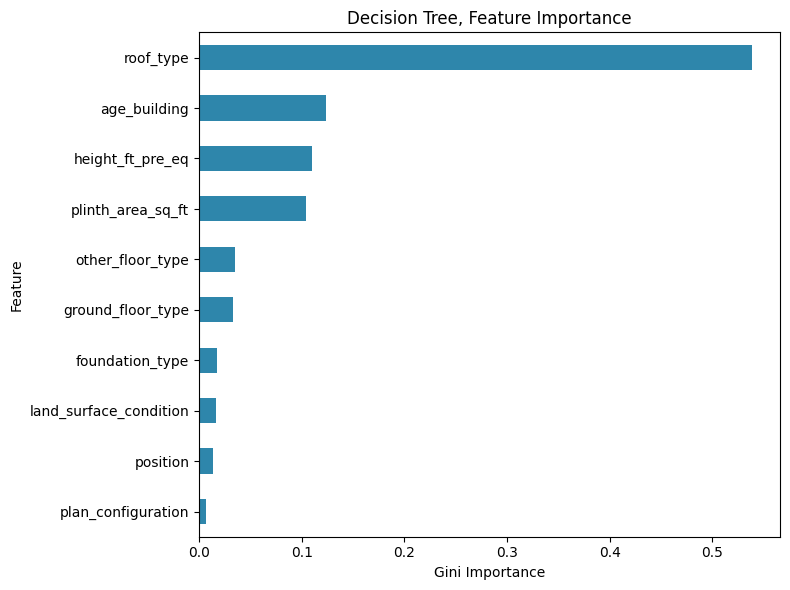

In [12]:
feat_imp.plot(kind="barh", color="#2E86AB", figsize=(8,6))
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("Decision Tree, Feature Importance")
plt.tight_layout()
plt.savefig("../images/dtree_feature_importance.png", dpi=150)
plt.show()


Roof type shows up as one of the strongest predictors here -- lines up with what the
EDA boxplot/pivot table already hinted at.

In [13]:
with open("../data/3_model_dtree_results.txt", "w") as f:
    f.write(str(acc_test))
print("saved:", acc_test)

saved: 0.6630789634768415
